In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# load datasets
daily_df = pd.read_csv("../data/raw/model_input_daily_2024_2025.csv")
hourly_df = pd.read_csv("../data/raw/caiso_load_2024_2025_hourly.csv")

print("Daily shape:", daily_df.shape)
print("Hourly shape:", hourly_df.shape)

daily_df.head()

Daily shape: (731, 43)
Hourly shape: (17527, 2)


,datetime,la_temp_mean,la_temp_max,la_temp_min,la_rhum_mean,la_prcp_sum,la_wspd_mean,sf_temp_mean,sf_temp_max,sf_temp_min,...,load_mw_min,load_mw_std,year,month,day,day_of_week,day_name,day_of_year,is_weekend,target_load_mw_mean
0,2024-01-01,13.991667,19.0,10.3,68.000000,0.0,7.750000,11.583333,14.4,8.6,...,16828.250000,2437.323535,2024,1,1,0,Monday,1,0,20606.559028
1,2024-01-02,13.175000,18.7,8.2,66.250000,0.0,9.825000,11.375000,16.6,8.2,...,19421.083333,2430.039108,2024,1,2,1,Tuesday,2,0,23300.965278
2,2024-01-03,13.670833,17.6,11.1,77.833333,2.5,9.633333,11.466667,14.4,9.1,...,20220.916667,2288.611332,2024,1,3,2,Wednesday,3,0,23571.142361
3,2024-01-04,13.991667,18.0,12.0,45.625000,0.0,14.450000,10.804167,14.8,7.7,...,20372.500000,2317.768825,2024,1,4,3,Thursday,4,0,23311.829861
4,2024-01-05,12.733333,18.7,8.2,50.333333,0.0,9.050000,12.612500,16.4,10.5,...,19445.666667,2301.631481,2024,1,5,4,Friday,5,0,23085.718750


In [3]:
daily_df.info()

print("\nMissing values:")
print(daily_df.isna().sum()[daily_df.isna().sum() > 0])

daily_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             731 non-null    object 
 1   la_temp_mean         731 non-null    float64
 2   la_temp_max          731 non-null    float64
 3   la_temp_min          731 non-null    float64
 4   la_rhum_mean         731 non-null    float64
 5   la_prcp_sum          731 non-null    float64
 6   la_wspd_mean         731 non-null    float64
 7   sf_temp_mean         731 non-null    float64
 8   sf_temp_max          731 non-null    float64
 9   sf_temp_min          731 non-null    float64
 10  sf_rhum_mean         731 non-null    float64
 11  sf_prcp_sum          731 non-null    float64
 12  sf_wspd_mean         731 non-null    float64
 13  sd_temp_mean         731 non-null    float64
 14  sd_temp_max          731 non-null    float64
 15  sd_temp_min          731 non-null    flo

,la_temp_mean,la_temp_max,la_temp_min,la_rhum_mean,la_prcp_sum,la_wspd_mean,sf_temp_mean,sf_temp_max,sf_temp_min,sf_rhum_mean,...,load_mw_max,load_mw_min,load_mw_std,year,month,day,day_of_week,day_of_year,is_weekend,target_load_mw_mean
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,...,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,17.427012,23.180575,13.251026,68.862574,1.002052,9.510317,14.606931,19.244733,11.462927,75.191119,...,29420.921341,19742.078089,3128.093093,2024.499316,6.519836,15.738714,2.991792,183.250342,0.284542,24042.659940
std,3.817151,4.672203,3.787150,13.650769,4.785750,2.993553,3.056053,4.191421,3.029618,9.690397,...,5135.349168,3086.637876,1113.783883,0.500342,3.451913,8.809949,2.002037,105.583202,0.451505,3561.864262
min,8.120833,11.800000,4.500000,11.500000,0.000000,4.079167,7.725000,11.500000,3.200000,33.958333,...,22797.166667,11020.750000,1055.000926,2024.000000,1.000000,1.000000,0.000000,1.000000,0.000000,17509.118056
25%,14.418750,19.400000,10.300000,65.291667,0.000000,7.381250,12.502083,16.000000,9.400000,70.604167,...,25845.416667,17842.458333,2331.401010,2024.000000,4.000000,8.000000,1.000000,92.000000,0.000000,21474.373264
50%,17.116667,22.900000,13.600000,71.625000,0.000000,9.070833,14.729167,19.000000,11.800000,76.708333,...,27369.416667,19655.666667,2792.507596,2024.000000,7.000000,16.000000,3.000000,183.000000,0.000000,23131.638889
75%,20.402083,26.400000,16.150000,76.833333,0.000000,11.293750,16.725000,21.600000,13.600000,81.562500,...,31978.416667,21789.083333,3671.028722,2025.000000,10.000000,23.000000,5.000000,274.500000,1.000000,26028.185764
max,32.020833,41.900000,23.900000,94.208333,61.600000,22.858333,26.187500,36.500000,20.400000,94.666667,...,47325.416667,27448.083333,7476.562633,2025.000000,12.000000,31.000000,6.000000,366.000000,1.000000,36137.364583


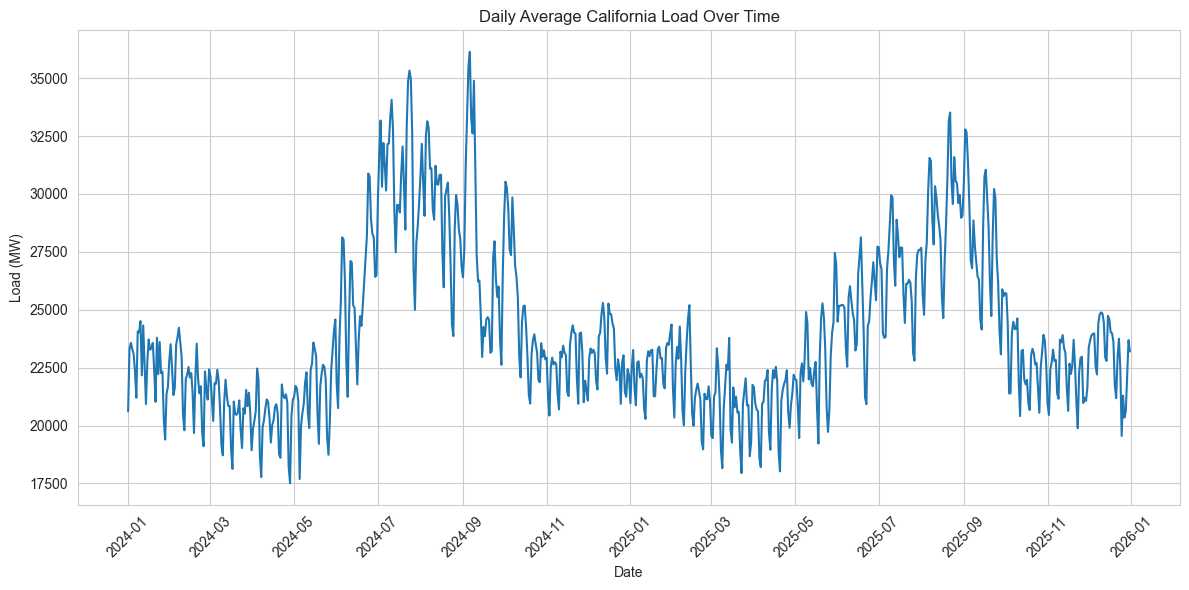

In [4]:
import matplotlib.dates as mdates

daily_df["datetime"] = pd.to_datetime(daily_df["datetime"])

plt.figure(figsize=(12,6))

plt.plot(daily_df["datetime"], daily_df["load_mw_mean"]) 

plt.title("Daily Average California Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load (MW)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

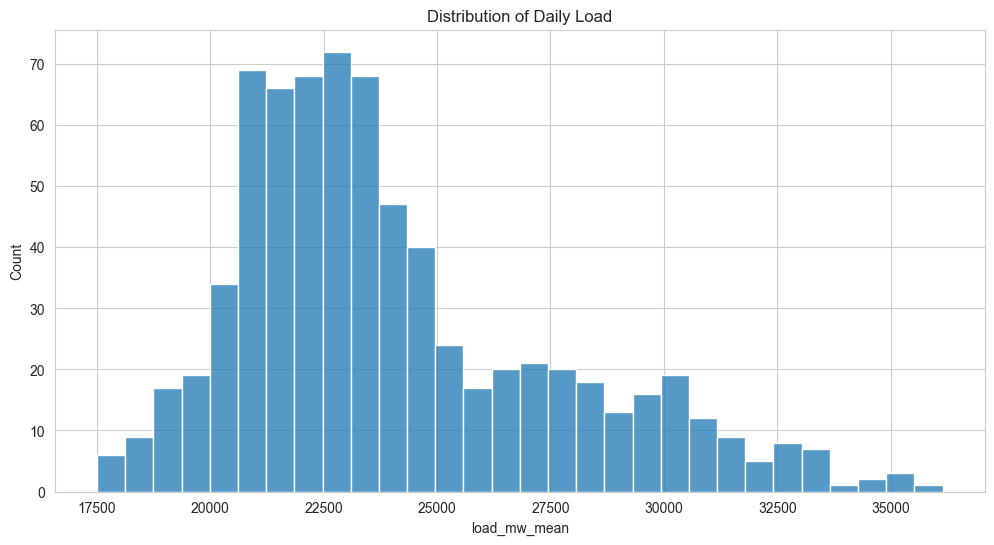

In [5]:
sns.histplot(daily_df["load_mw_mean"], bins=30)
plt.title("Distribution of Daily Load")
plt.show()

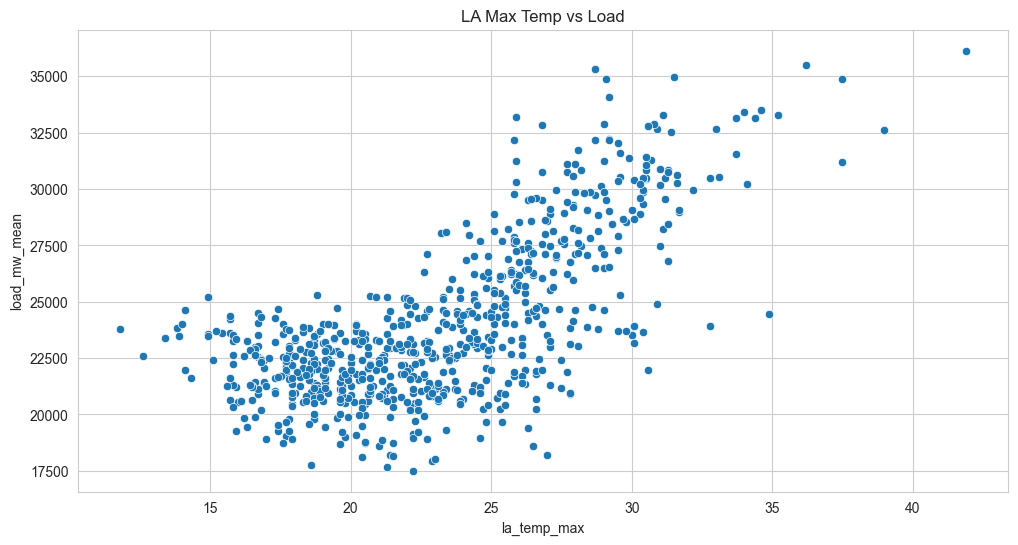

In [6]:
sns.scatterplot(
    data=daily_df,
    x="la_temp_max",
    y="load_mw_mean"
)
plt.title("LA Max Temp vs Load")
plt.show()

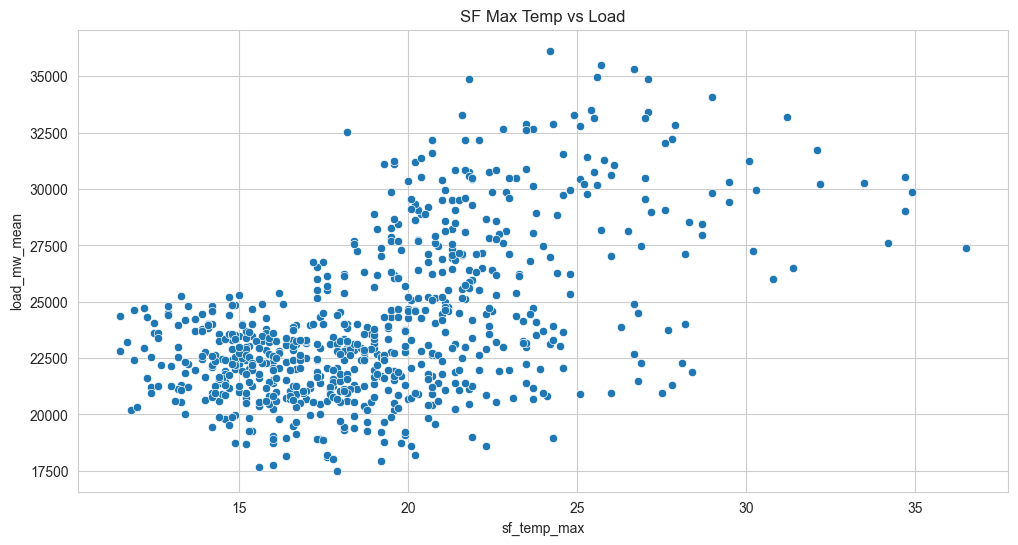

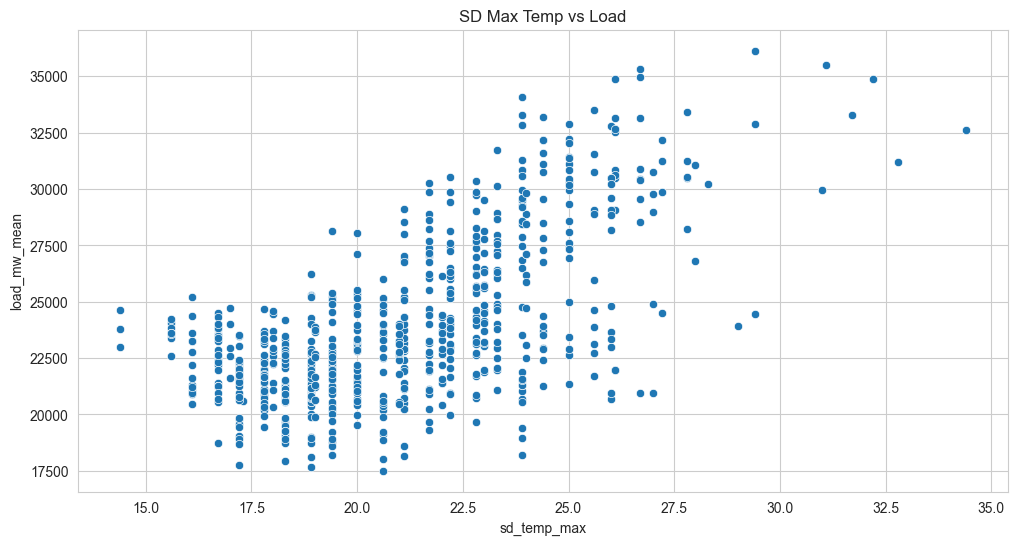

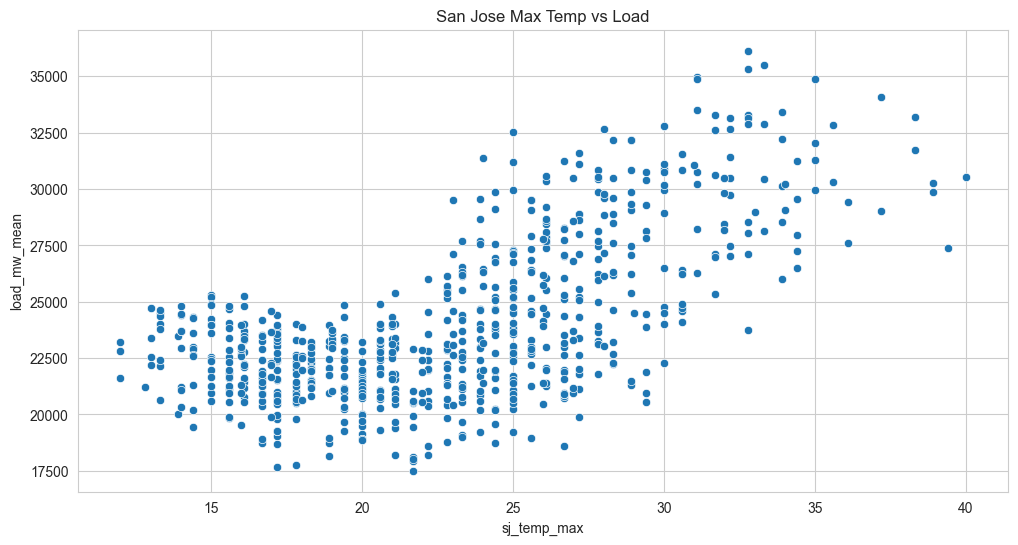

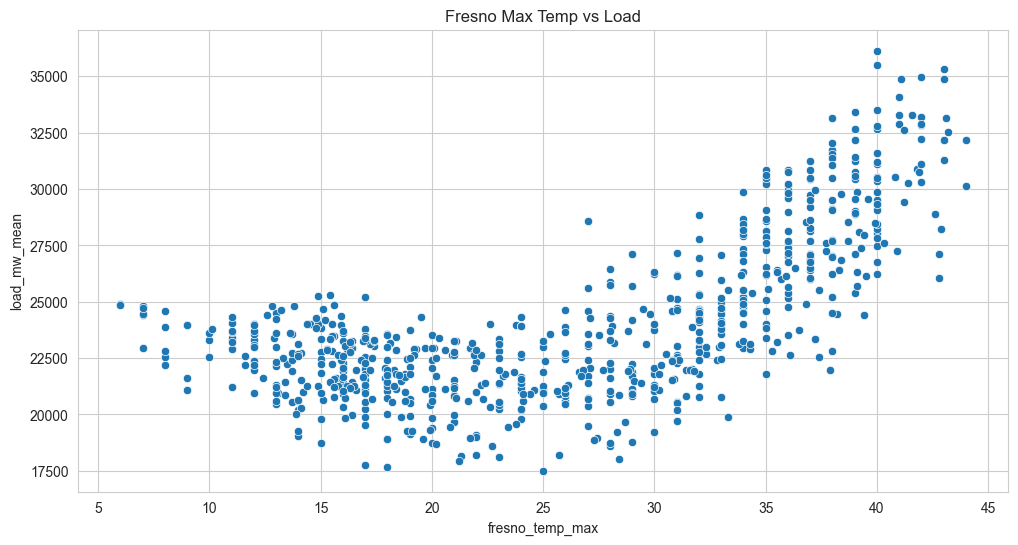

In [7]:
sns.scatterplot(data=daily_df, x="sf_temp_max", y="load_mw_mean")
plt.title("SF Max Temp vs Load")
plt.show()

sns.scatterplot(data=daily_df, x="sd_temp_max", y="load_mw_mean")
plt.title("SD Max Temp vs Load")
plt.show()

sns.scatterplot(data=daily_df, x="sj_temp_max", y="load_mw_mean")
plt.title("San Jose Max Temp vs Load")
plt.show()

sns.scatterplot(data=daily_df, x="fresno_temp_max", y="load_mw_mean")
plt.title("Fresno Max Temp vs Load")
plt.show()

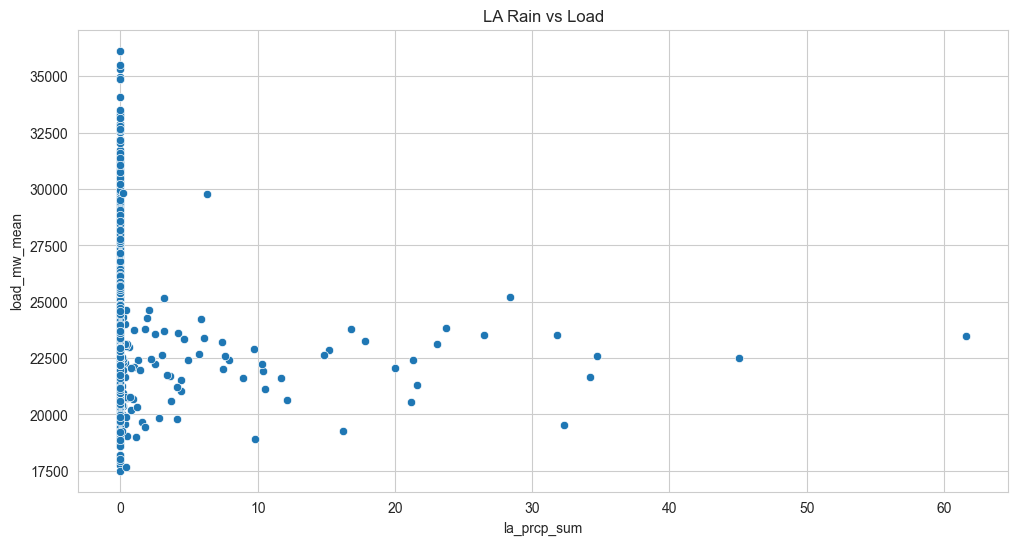

In [8]:
sns.scatterplot(data=daily_df, x="la_prcp_sum", y="load_mw_mean")
plt.title("LA Rain vs Load")
plt.show()

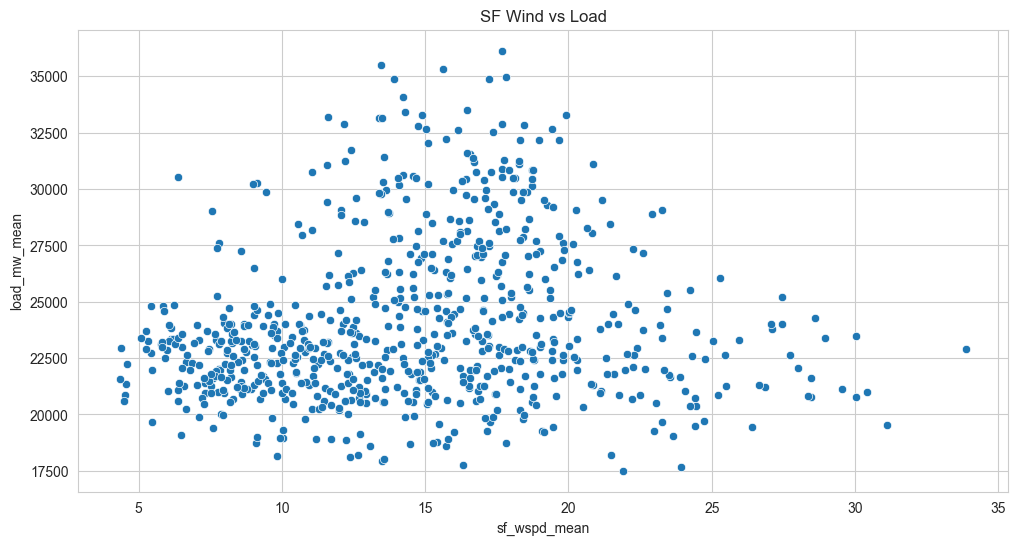

In [9]:
sns.scatterplot(data=daily_df, x="sf_wspd_mean", y="load_mw_mean")
plt.title("SF Wind vs Load")
plt.show()

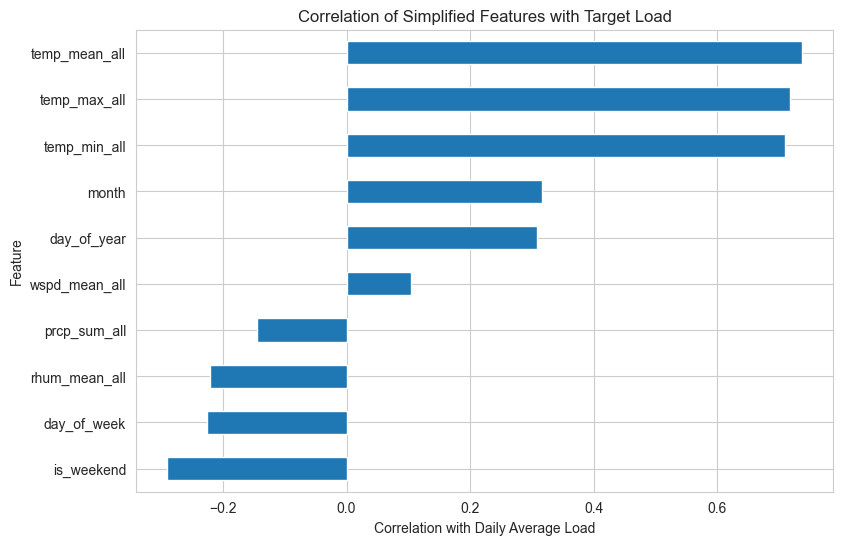

In [10]:
# aggregated weather features across cities
daily_df["temp_mean_all"] = daily_df[["la_temp_mean", "sf_temp_mean", "sd_temp_mean", "sj_temp_mean", "fresno_temp_mean"]].mean(axis=1)
daily_df["temp_max_all"] = daily_df[["la_temp_max", "sf_temp_max", "sd_temp_max", "sj_temp_max", "fresno_temp_max"]].mean(axis=1)
daily_df["temp_min_all"] = daily_df[["la_temp_min", "sf_temp_min", "sd_temp_min", "sj_temp_min", "fresno_temp_min"]].mean(axis=1)

daily_df["rhum_mean_all"] = daily_df[["la_rhum_mean", "sf_rhum_mean", "sd_rhum_mean", "sj_rhum_mean", "fresno_rhum_mean"]].mean(axis=1)
daily_df["prcp_sum_all"] = daily_df[["la_prcp_sum", "sf_prcp_sum", "sd_prcp_sum", "sj_prcp_sum", "fresno_prcp_sum"]].mean(axis=1)
daily_df["wspd_mean_all"] = daily_df[["la_wspd_mean", "sf_wspd_mean", "sd_wspd_mean", "sj_wspd_mean", "fresno_wspd_mean"]].mean(axis=1)

eda_cols = [
    "temp_mean_all",
    "temp_max_all",
    "temp_min_all",
    "rhum_mean_all",
    "prcp_sum_all",
    "wspd_mean_all",
    "month",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "target_load_mw_mean"
]

target_corr_simple = (
    daily_df[eda_cols]
    .corr(numeric_only=True)["target_load_mw_mean"]
    .drop("target_load_mw_mean")
    .sort_values()
)

plt.figure(figsize=(9, 6))
target_corr_simple.plot(kind="barh")
plt.title("Correlation of Simplified Features with Target Load")
plt.xlabel("Correlation with Daily Average Load")
plt.ylabel("Feature")
plt.show()

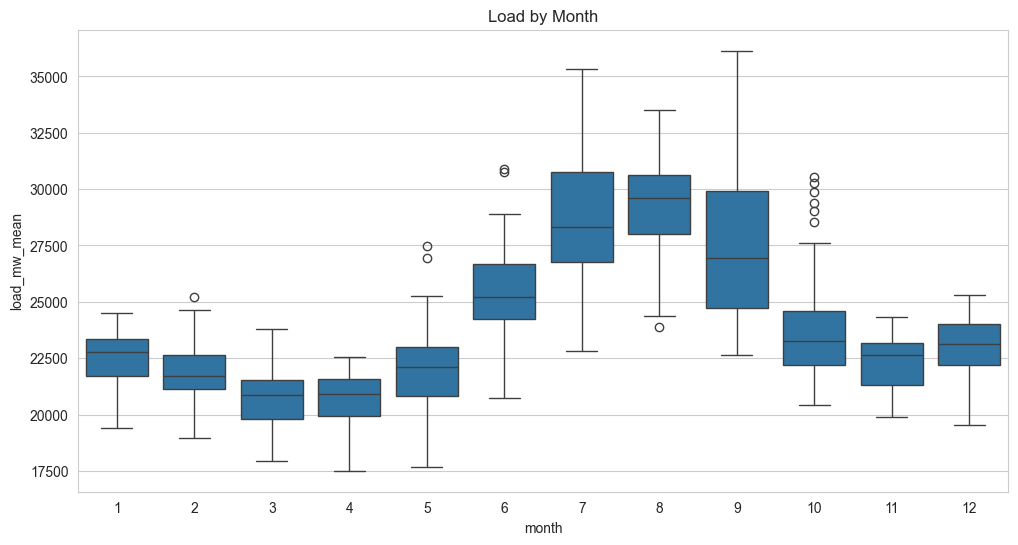

In [11]:
sns.boxplot(x="month", y="load_mw_mean", data=daily_df)
plt.title("Load by Month")
plt.show()

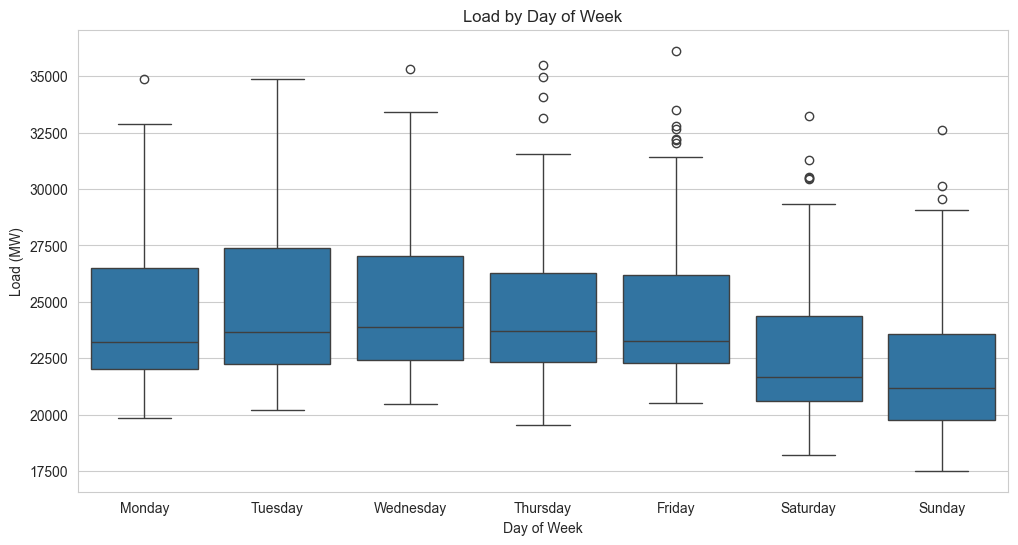

In [12]:
sns.boxplot(
    x="day_name",
    y="load_mw_mean",
    data=daily_df,
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.title("Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Load (MW)")
plt.show()

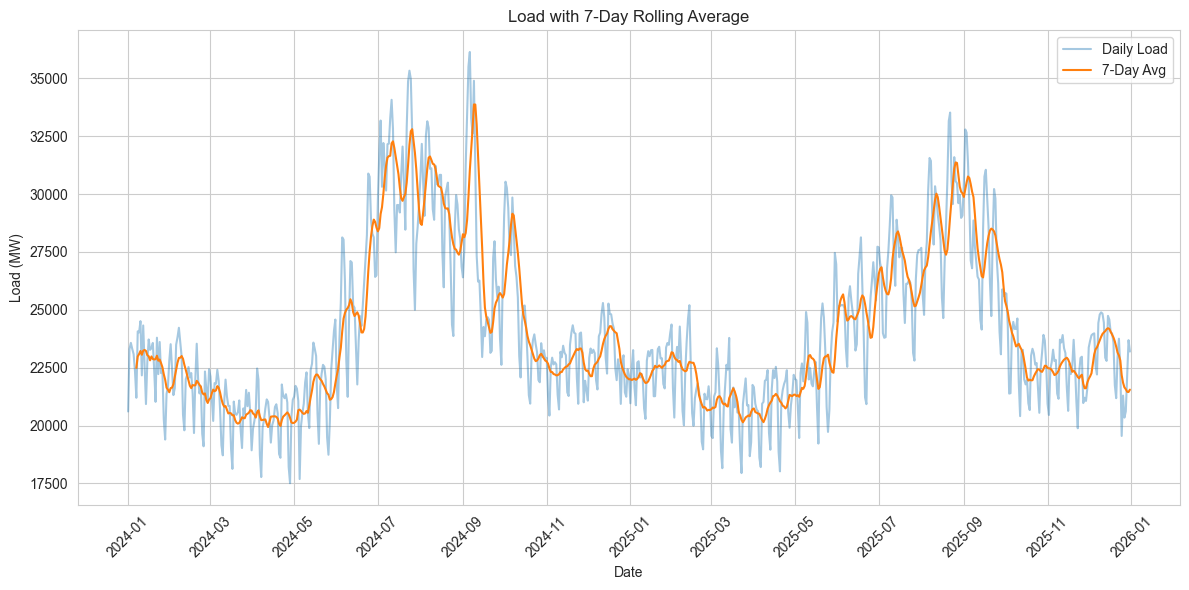

In [13]:

daily_df["datetime"] = pd.to_datetime(daily_df["datetime"])

daily_df["rolling_7"] = daily_df["load_mw_mean"].rolling(7).mean()

plt.figure(figsize=(12,6))

plt.plot(daily_df["datetime"], daily_df["load_mw_mean"], alpha=0.4, label="Daily Load")
plt.plot(daily_df["datetime"], daily_df["rolling_7"], label="7-Day Avg")

plt.title("Load with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Load (MW)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

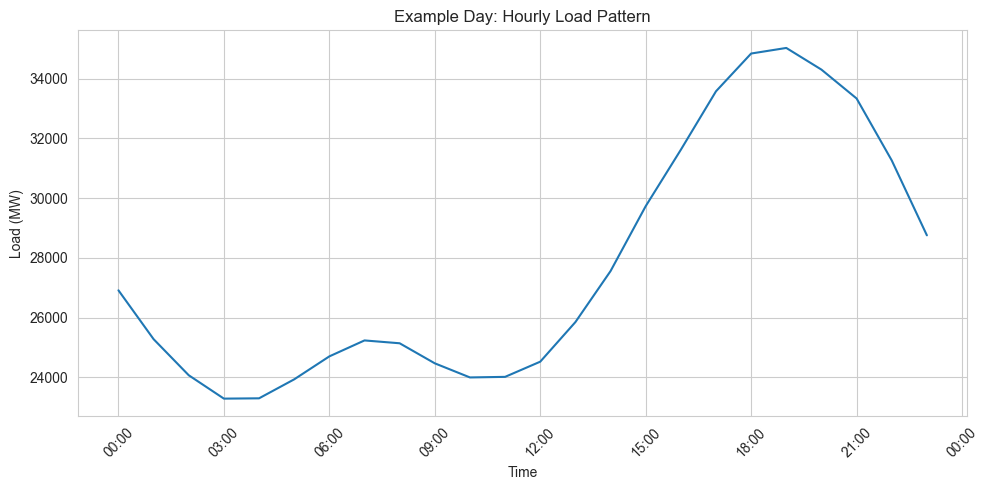

In [14]:
# force everything to parse as UTC first
hourly_df["datetime"] = pd.to_datetime(hourly_df["Time"], utc=True)

# convert to California time, then remove timezone so plotting/filtering is easier
hourly_df["datetime"] = (
    hourly_df["datetime"]
    .dt.tz_convert("America/Los_Angeles")
    .dt.tz_localize(None)
)

sample_day = hourly_df[
    (hourly_df["datetime"] >= pd.Timestamp("2025-07-01")) &
    (hourly_df["datetime"] < pd.Timestamp("2025-07-02"))
]

plt.figure(figsize=(10, 5))
plt.plot(sample_day["datetime"], sample_day["Load"])
plt.title("Example Day: Hourly Load Pattern")
plt.xlabel("Time")
plt.ylabel("Load (MW)")

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## EDA Summary

- **Clear seasonal pattern in demand**
  - Load rises from spring into late summer, peaking around August–September, then declines into winter.
  - Consistent with increased cooling demand.

- **Temperature is the dominant driver**
  - Higher temperatures strongly correlate with higher load, especially max temperature.
  - Signal is strongest in LA but present across all cities.

- **Weekday vs weekend effect**
  - Demand is higher on weekdays and lowest on Sundays.
  - Likely driven by commercial and industrial activity.

- **Consistent daily load cycle**
  - Hourly data shows predictable patterns: low overnight, ramp in the morning, peak in late afternoon/evening.

- **Other weather features are weaker**
  - Humidity, wind, and precipitation show relatively low correlation with load.
  - Precipitation has a slight negative relationship.

- **Calendar features add important signal**
  - Month and day-of-year capture seasonality.
  - Day-of-week and weekend flags capture behavior patterns.

- **Multi-city weather improves representation**
  - Combining LA, SF, and SD better reflects statewide conditions than a single location.

---

**Takeaway:**  
California electricity demand is driven primarily by temperature, with additional influence from seasonality and human behavior patterns. These insights guide feature selection for modeling.